# Visualizing clusters in sensor space

One of the challenges of cluster analysis is that clusters are multidimensional and therefore difficult to visualize. Here we will see the various options for visualizing clusters in sensor space.

## Preliminaries

### Setting up the data and fitting the model

We will fit a simple behaviour PLS model for illustration.

In [9]:
import mne
from mne.datasets import kiloword
import mne_plsc

# Load the data
path = kiloword.data_path() / "kword_metadata-epo.fif"
epochs = mne.read_epochs(path)
# Fit a model
res = mne_plsc.fit_beh(epochs,
                       design=epochs.metadata,
                       covariates='Concreteness',
                       random_state=123)

Reading C:\Users\isaac\mne_data\MNE-kiloword-data\kword_metadata-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -100.00 ...     920.00 ms
        0 CTF compensation matrices available
Adding metadata with 8 columns
960 matching events found
No baseline correction applied
0 projection items activated


### Adding clusters

Next, we will computer clusters. To save time, we will perform cluster analysis on the raw saliences rather than the $z$-scores computed by boostrap resampling.

In [10]:
res.add_adjacency()
res.cluster()

Defaulting to all channels adjacent for ERP/ERF analysis
Clustering saliences
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
10 clusters


As we can see below, although 10 clusters were identified, most of the strong loading fall into the first cluster, so that is the one we will visualize.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

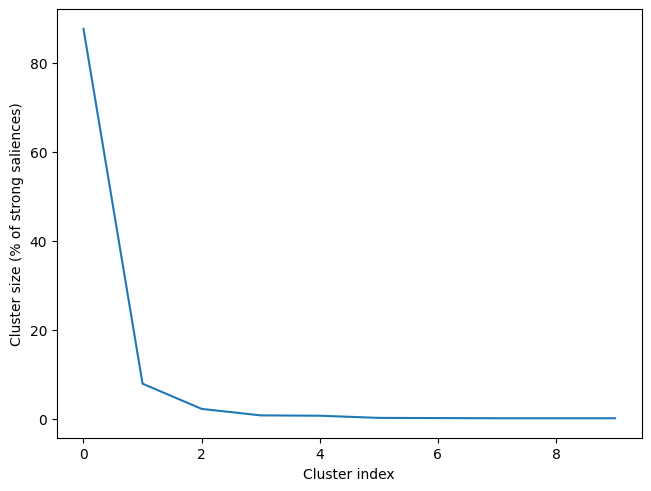

In [11]:
res.plot_cluster_sizes(lv_idx=0)

## Visualizing the non-spatial dimension(s)

The first challenge is how to plot the cluster over the non-spatial dimension, which is time in this case but could also be frequency (both time and frequency are the non-spatial dimensions for time-frequency analysis). The options for ERP data, which we will see in turn here are:

- Butterfly plots
- Raster plots
- Distribution plots

### Butterfly plots

A butterfly plot displays a time course for each channel with a colour that is informative about channel location. 

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Salience'>)

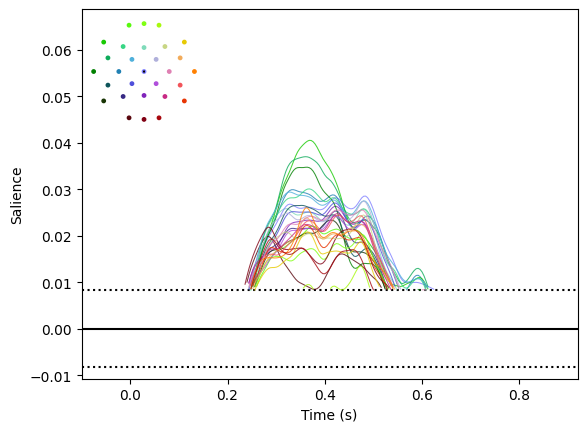

In [12]:
res.plot_cluster_nonspatial(lv_idx=0, cluster_idx=0, plot_type='butterfly')

### Raster plots

`plot_type='raster'` generates a raster image in which each row is a separate channel.

(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='Time (s)'>)

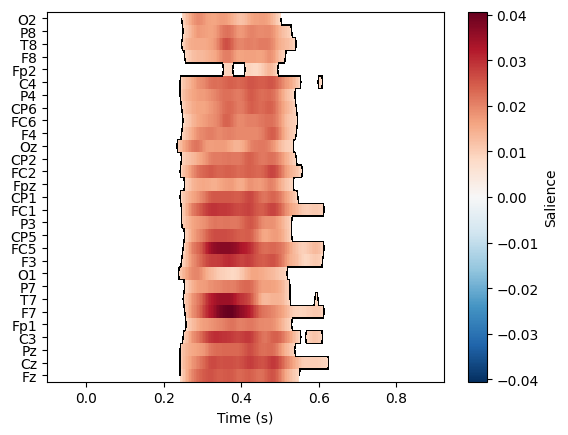

In [13]:
res.plot_cluster_nonspatial(lv_idx=0, cluster_idx=0, plot_type='raster')

### Distribution plots

A distribution plot doesn't display the data itself but instead shows the distribution of the number of channels present in the cluster.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='N. channels in cluster'>)

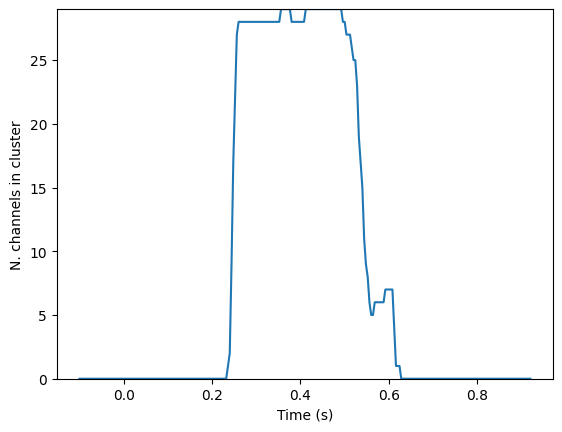

In [14]:
res.plot_cluster_nonspatial(lv_idx=0, cluster_idx=0, plot_type='distribution')

## Visualizing the spatial dimension

Below, we can see several options for representing the spatial distribution of a cluster using a topomap.

### Plotting at the cluster peak

One option is to look at the spatial distribution of the saliences at the peak within the cluster.

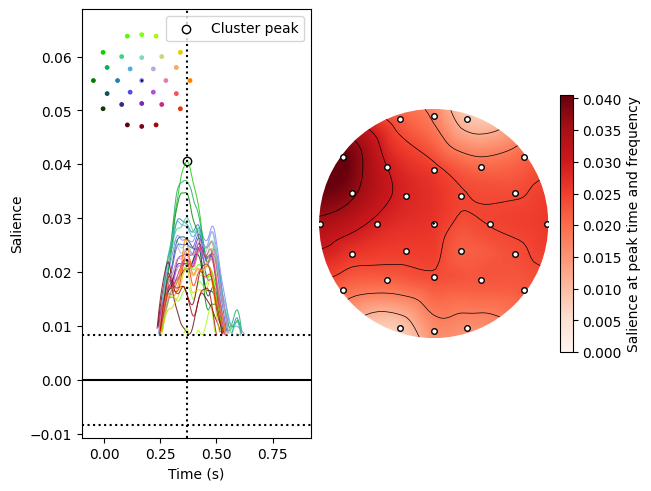

In [15]:
res.plot_clusters(lv_idx=0, cluster_idx=0, highlight='peak')

### Plotting within the cluster extent

Alternatively, we can plot saliences averaged over the cluster extent (in this case, its temporal extent).

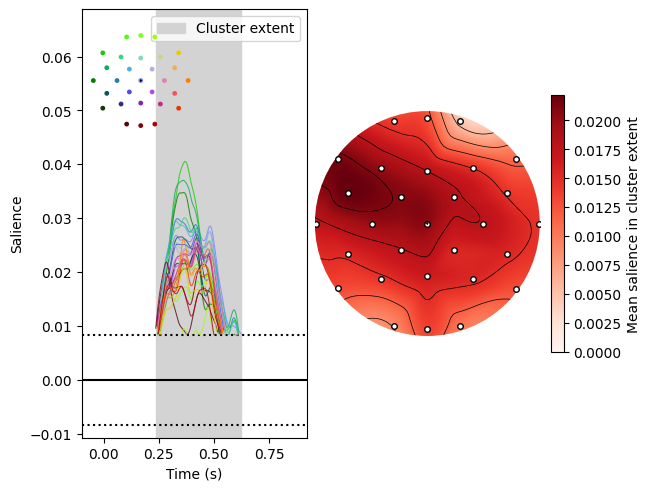

In [16]:
res.plot_clusters(lv_idx=0, cluster_idx=0, highlight='extent')

Note that we have plotted both the spatial and non-spatial dimensions here for ease of interpretation, but the spatial plots only can 